# Нейронная сеть прямого распространения — регрессор

Ниже показан полный пример применения **нейронной сети прямого распространения для регрессии** (англ. *feedforward neural network*, она же *многослойный перцептрон*, MLP — Multi-Layer Perceptron) — модели, состоящей из последовательных слоёв «нейронов», где сигнал идёт только вперёд: от входа к выходу, без обратных связей, и предсказывает числовое значение (например, цену, спрос, показатель здоровья).


## 1. Название и краткая информация о методе (1 абзац)

**Нейронная сеть прямого распространения (регрессор)** — это модель машинного обучения, состоящая из нескольких последовательных слоёв искусственных нейронов. Каждый нейрон считает взвешенную сумму входов, пропускает её через функцию активации (нелинейное преобразование, например «выпрямитель» ReLU — Rectified Linear Unit) и передаёт результат на следующий слой. Веса подбираются алгоритмом обратного распространения ошибки (англ. *backpropagation*): сеть делает прогноз, сравнивает его с правильным ответом, считает ошибку и маленькими шагами корректирует веса, чтобы ошибка уменьшалась. В отличие от линейных моделей, сеть умеет улавливать сложные нелинейные зависимости между признаками и целью, но требует масштабирования данных (приведение к одному масштабу) и аккуратного подбора количества скрытых слоёв и нейронов, чтобы не переобучиться.


## 2. Используемые библиотеки

In [1]:
# Если вы запускаете в Google Colab, обычно всё уже установлено.
# Этот блок оставлен для надёжности: установит пакеты, если их вдруг нет.

import sys, subprocess, pkgutil

def pip_install(package_name: str):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

required = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
]

for import_name, pip_name in required:
    if pkgutil.find_loader(import_name) is None:
        pip_install(pip_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)


/tmp/ipykernel_5307/2137559190.py:18: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader(import_name) is None:


## 3. Описание и демонстрация (частичная распечатка) датасета

In [2]:
# Возьмём встроенный набор данных для регрессии из scikit-learn: California Housing.
# Он загружается автоматически, содержит реальные данные о жилье в Калифорнии
# и подходит для демонстрации регрессии нейронной сетью.

data = fetch_california_housing(as_frame=True)
df = data.frame  # таблица с признаками и целевой переменной (MedHouseVal)

print("Размер таблицы:", df.shape)
print("Признаки:", list(data.feature_names))
print("Целевая переменная: MedHouseVal — медианная стоимость жилья в районе (в сотнях тысяч долларов)")

df.head(10)


Размер таблицы: (20640, 9)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Целевая переменная: MedHouseVal — медианная стоимость жилья в районе (в сотнях тысяч долларов)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


**Коротко о данных:** каждая строка — один район в Калифорнии, столбцы — числовые признаки района (средний доход жителей, возраст домов, количество комнат и т.п.), а `MedHouseVal` — число, которое мы хотим предсказать (медианная цена жилья).


## 4. Предварительная обработка датасета

In [3]:
# Проверим пропуски и подготовим X (признаки) и y (цель).

missing = df.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({"пропуски": missing}).head(15))

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Разделим на обучающую и тестовую части.
# Обучающая — чтобы учиться, тестовая — чтобы честно проверить качество.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, " | X_test:", X_test.shape)
print("y_train:", y_train.shape, " | y_test:", y_test.shape)

# Для нейронной сети обязательно нужно масштабирование признаков
# (приведение к одному масштабу, например, к среднему 0 и разбросу 1),
# иначе градиентный спуск будет медленно сходиться или «застревать».
# Масштабирование сделаем прямо внутри конвейера в блоке 6.


,пропуски
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


X_train: (16512, 8)  | X_test: (4128, 8)
y_train: (16512,)  | y_test: (4128,)


## 5. Тепловая карта

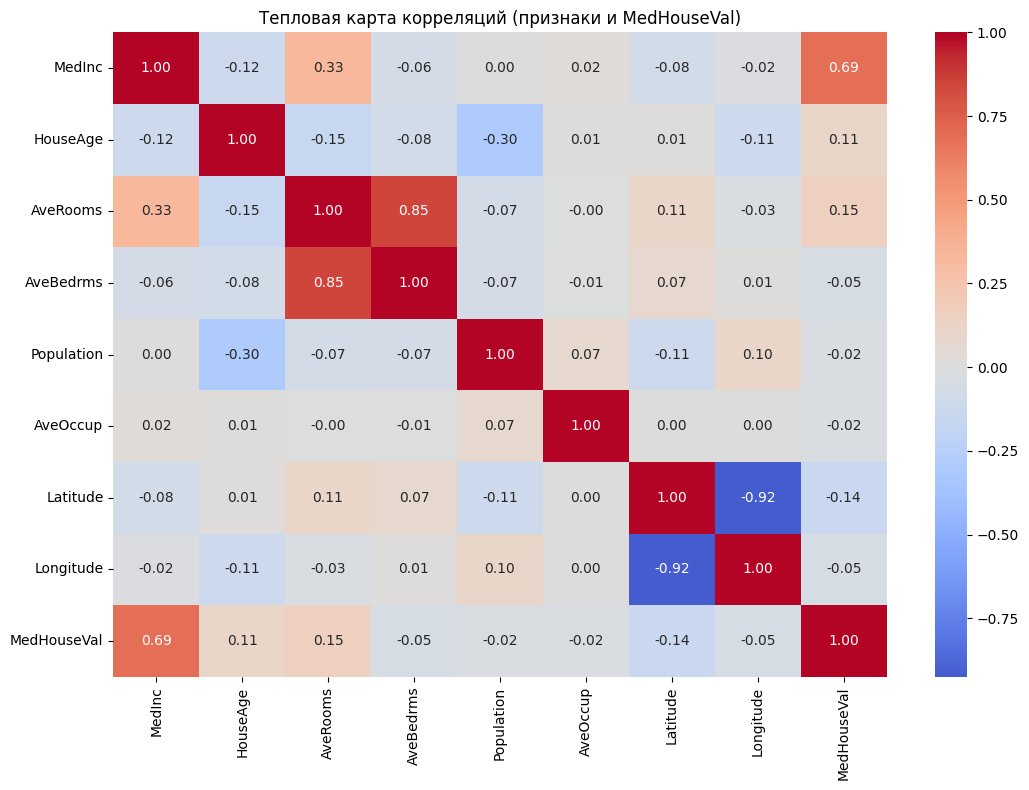

In [4]:
# Тепловая карта (англ. heatmap — «карта нагрева») корреляций показывает,
# как признаки связаны друг с другом и с целью.
# Корреляция близкая к 1 или -1 означает сильную линейную связь, близкая к 0 — слабую.

corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=False)
plt.title("Тепловая карта корреляций (признаки и MedHouseVal)")
plt.tight_layout()
plt.show()


## 6. Обучение модели

In [5]:
# Соберём конвейер (англ. pipeline — «цепочка шагов»):
#   1) заполним возможные пропуски медианой,
#   2) отмасштабируем признаки (StandardScaler — приводит каждый признак
#      к среднему 0 и стандартному отклонению 1),
#   3) обучим нейронную сеть прямого распространения (MLPRegressor).
#
# Архитектура сети:
#   hidden_layer_sizes=(64, 32) — два скрытых слоя: 64 и 32 нейрона.
#   activation="relu"           — функция активации «выпрямитель» (ReLU),
#                                 стандартный выбор для скрытых слоёв.
#   solver="adam"               — оптимизатор Adam (адаптивный метод на основе
#                                 градиентного спуска, хорошо работает «из коробки»).
#   max_iter=300                — максимум эпох (полных проходов по обучающим данным).
#   early_stopping=True         — ранняя остановка: прекратить обучение, если
#                                 качество на валидационной части перестаёт расти
#                                 (это защищает от переобучения).

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,              # регуляризация (штраф за большие веса)
        batch_size=256,          # размер пакета (batch) — сколько примеров
                                 # сеть обрабатывает за один шаг обучения
        learning_rate_init=1e-3, # начальный шаг обучения (learning rate)
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1, # доля обучающих данных на валидацию
        n_iter_no_change=15,     # если качество не растёт 15 эпох — стоп
        random_state=42,
        verbose=False,
    ))
])

model


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('mlp',
                 MLPRegressor(batch_size=256, early_stopping=True,
                              hidden_layer_sizes=(64, 32), max_iter=300,
                              n_iter_no_change=15, random_state=42))])

In [6]:
# Обучаем модель
model.fit(X_train, y_train)

# Оценим качество на тестовой части
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)                            # средняя абсолютная ошибка
rmse = np.sqrt(mean_squared_error(y_test, y_pred))                   # корень из средней квадратичной ошибки
r2 = r2_score(y_test, y_pred)                                        # коэффициент детерминации

print(f"MAE  (средняя абсолютная ошибка): {mae:.3f}")
print(f"RMSE (среднеквадратичная ошибка, корень): {rmse:.3f}")
print(f"R^2  (доля объяснённой вариации): {r2:.3f}")

mlp = model.named_steps["mlp"]
print(f"Число пройденных эпох: {mlp.n_iter_}")
print(f"Число слоёв (с входом и выходом): {mlp.n_layers_}")
print(f"Размеры скрытых слоёв: {mlp.hidden_layer_sizes}")


MAE  (средняя абсолютная ошибка): 0.359
RMSE (среднеквадратичная ошибка, корень): 0.531
R^2  (доля объяснённой вариации): 0.785
Число пройденных эпох: 98
Число слоёв (с входом и выходом): 4
Размеры скрытых слоёв: (64, 32)


## 7. Прогнозы модели

In [7]:
# Посмотрим примеры прогнозов: истинное значение vs предсказание.
# MedHouseVal — в сотнях тысяч долларов (например, 2.5 = 250 000 $).

preview = pd.DataFrame({
    "Истинное MedHouseVal": y_test.values,
    "Прогноз модели": y_pred,
    "Ошибка (истинное - прогноз)": y_test.values - y_pred,
})

preview.head(12)


,Истинное MedHouseVal,Прогноз модели,Ошибка (истинное - прогноз)
0,0.47700,0.502771,-0.025771
1,0.45800,1.264542,-0.806542
2,5.00001,4.701002,0.299008
3,2.18600,2.548951,-0.362951
4,2.78000,2.605392,0.174608
5,1.58700,1.541831,0.045169
6,1.98200,2.406452,-0.424452
7,1.57500,1.604123,-0.029123
8,3.40000,2.268640,1.131360
9,4.46600,4.553662,-0.087662


## 8. Графики выходных результатов

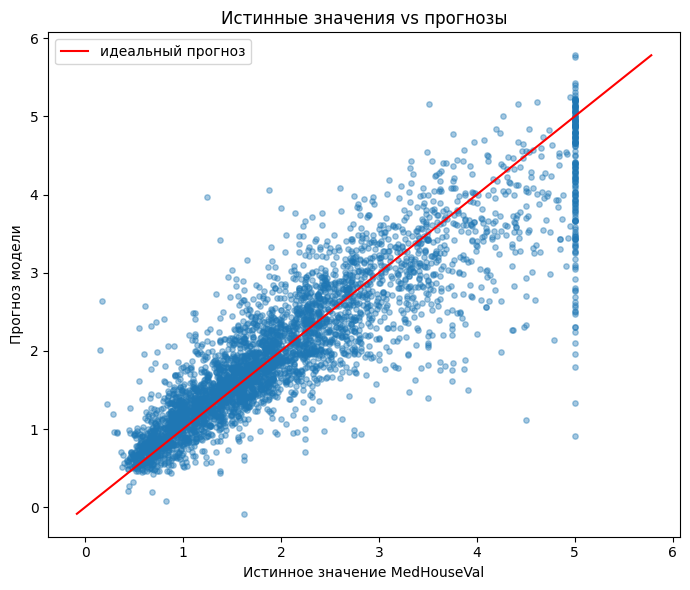

In [8]:
# 8.1 Диаграмма: истинные значения vs прогнозы.
# Идеально — все точки лежат на диагонали (прогноз = истина).

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linewidth=1.5, label="идеальный прогноз")
plt.xlabel("Истинное значение MedHouseVal")
plt.ylabel("Прогноз модели")
plt.title("Истинные значения vs прогнозы")
plt.legend()
plt.tight_layout()
plt.show()


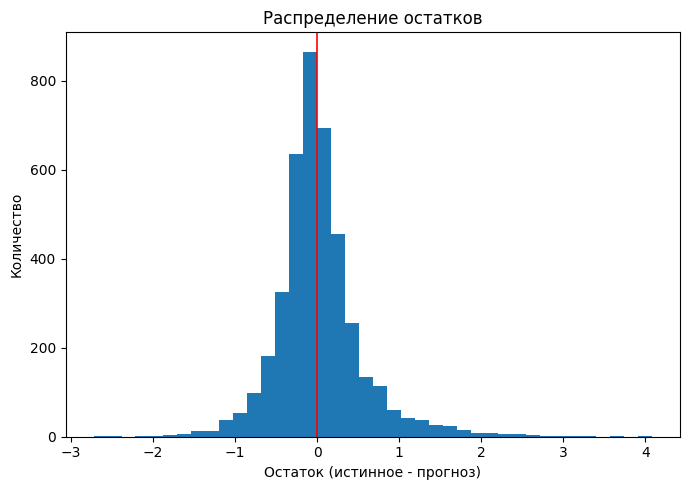

In [9]:
# 8.2 Остатки (ошибки) = истинное - прогноз.
# Хорошо, когда они «в среднем около нуля» без сильного смещения.

residuals = y_test.values - y_pred

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=40)
plt.axvline(0, color="red", linewidth=1.2)
plt.xlabel("Остаток (истинное - прогноз)")
plt.ylabel("Количество")
plt.title("Распределение остатков")
plt.tight_layout()
plt.show()


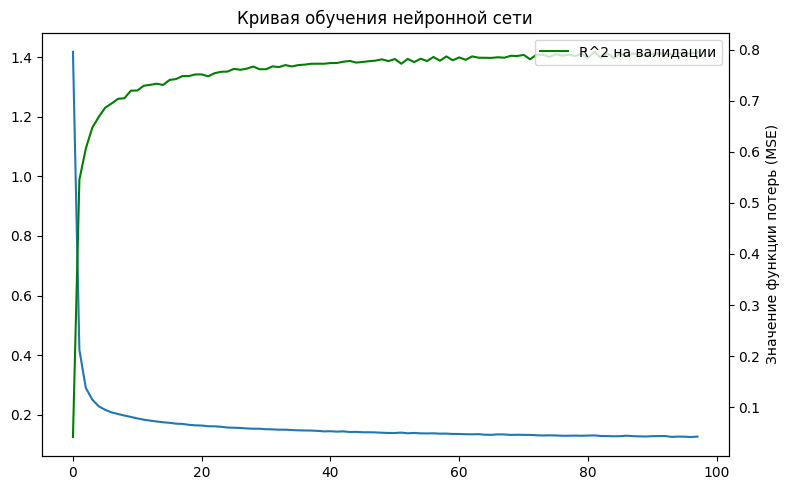

In [10]:
# 8.3 Кривая обучения (loss curve) — как убывала ошибка на обучающей части
# от эпохи к эпохе. Если кривая вышла на «плато» — сеть дообучилась.

mlp = model.named_steps["mlp"]

plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label="Ошибка на обучении (loss)")
if hasattr(mlp, "validation_scores_") and mlp.validation_scores_ is not None:
    # validation_scores_ — это R^2 на валидации (чем выше — тем лучше),
    # отрисуем его на второй оси для наглядности.
    ax2 = plt.gca().twinx()
    ax2.plot(mlp.validation_scores_, color="green", label="R^2 на валидации")
    ax2.set_ylabel("R^2 на валидации")
    ax2.legend(loc="lower right")
plt.gca().set_xlabel("Эпоха обучения")
plt.gca().set_ylabel("Значение функции потерь (MSE)")
plt.title("Кривая обучения нейронной сети")
plt.gca().legend(loc="upper right")
plt.tight_layout()
plt.show()


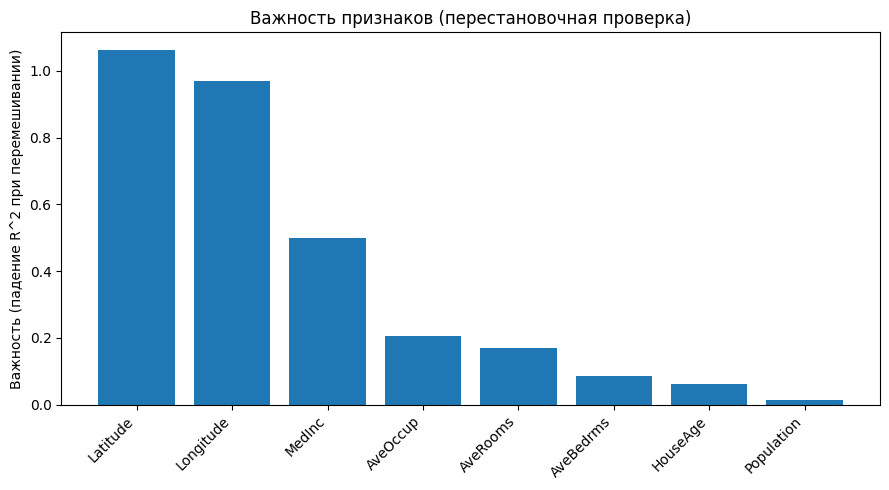

,важность
Latitude,1.061849
Longitude,0.969478
MedInc,0.499652
AveOccup,0.205980
AveRooms,0.170375
AveBedrms,0.086127
HouseAge,0.060855
Population,0.014149


In [11]:
# 8.4 Важность признаков через перестановочную проверку
# (англ. permutation importance — «перестановочная важность»).
# У нейронной сети нет встроенного атрибута feature_importances_,
# поэтому мы проверяем важность экспериментально:
# по очереди перемешиваем значения каждого признака и смотрим,
# насколько ухудшается качество. Чем сильнее упало качество —
# тем важнее был этот признак.

perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1, scoring="r2"
)

importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Важность (падение R^2 при перемешивании)")
plt.title("Важность признаков (перестановочная проверка)")
plt.tight_layout()
plt.show()

importances.to_frame("важность").head(10)


---

### Короткий вывод
Нейронная сеть прямого распространения (многослойный перцептрон) обучилась на масштабированных числовых признаках и даёт прогнозы медианной стоимости жилья. Качество оценено метриками MAE, RMSE и R²; графики показывают соответствие прогнозов истинным значениям, распределение ошибок, кривую обучения сети по эпохам и важность признаков, определённую перестановочной проверкой.
